In [1]:
!pip install prophet

  Using cached cmdstanpy-1.3.0-py3-none-any.whl.metadata (4.2 kB)
  Using cached holidays-0.98-py3-none-any.whl.metadata (53 kB)
  Using cached importlib_resources-7.1.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached stanio-0.5.1-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   -----------------------------

In [2]:
import pandas as pd
import numpy as np

from prophet import Prophet

import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(
    "../data/daily_sales.csv"
)

df.head()

,Date,Sales
0,2010-12-01,46192.49
1,2010-12-02,47197.57
2,2010-12-03,23876.63
3,2010-12-05,31361.28
4,2010-12-06,31009.33


In [5]:
df = df.rename(
    columns={
        "Date":"ds",
        "Sales":"y"
    }
)

df.head()

,ds,y
0,2010-12-01,46192.49
1,2010-12-02,47197.57
2,2010-12-03,23876.63
3,2010-12-05,31361.28
4,2010-12-06,31009.33


In [6]:
df["ds"] = pd.to_datetime(
    df["ds"]
)

In [7]:
print(df.shape)

df.info()

(305, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      305 non-null    datetime64[ns]
 1   y       305 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 4.9 KB


In [8]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

In [9]:
model.fit(df)

23:03:21 - cmdstanpy - INFO - Chain [1] start processing
23:03:22 - cmdstanpy - INFO - Chain [1] done processing


In [10]:
future = model.make_future_dataframe(
    periods=30
)

future.tail()

,ds
330,2012-01-04
331,2012-01-05
332,2012-01-06
333,2012-01-07
334,2012-01-08


In [11]:
forecast = model.predict(
    future
)

In [12]:
forecast[
    ["ds","yhat","yhat_lower","yhat_upper"]
].tail()

,ds,yhat,yhat_lower,yhat_upper
330,2012-01-04,43424.884911,26906.719095,58971.474983
331,2012-01-05,51693.504735,34816.784192,68067.781468
332,2012-01-06,44651.236885,28371.336964,62306.983173
333,2012-01-07,62772.299825,47121.197602,79687.833500
334,2012-01-08,33717.145805,18096.509170,51524.986323


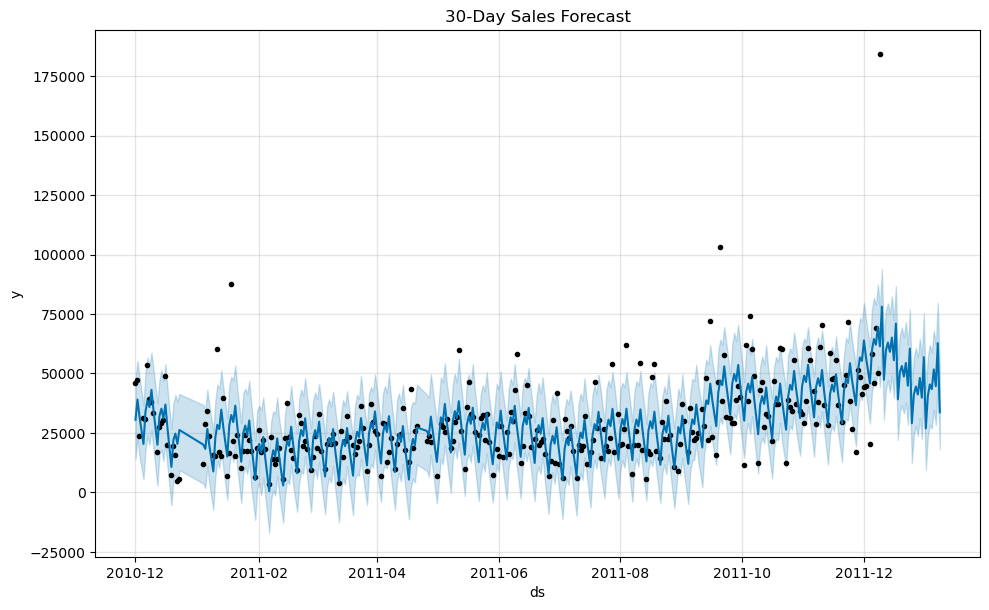

In [13]:
fig = model.plot(
    forecast
)

plt.title(
    "30-Day Sales Forecast"
)

plt.show()

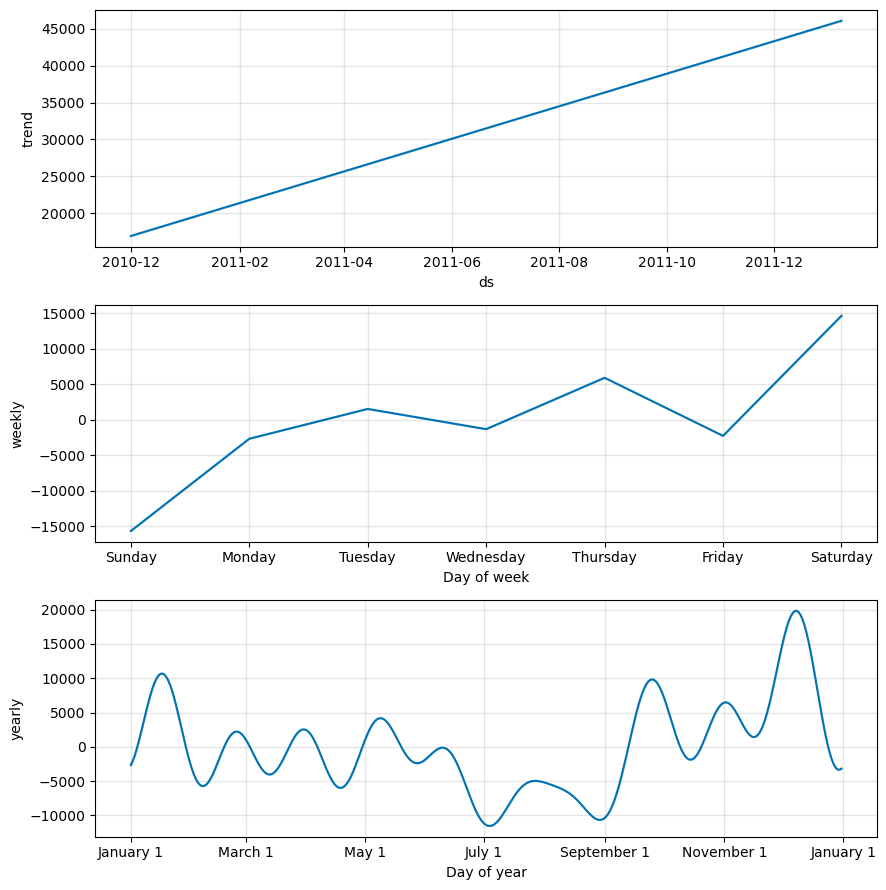

In [14]:
model.plot_components(
    forecast
)

plt.show()

In [15]:
future_sales = forecast.tail(30)

future_sales[
    ["ds","yhat"]
]

,ds,yhat
305,2011-12-10,78109.165063
306,2011-12-11,47356.913283
307,2011-12-12,59679.835550
308,2011-12-13,63011.027519
309,2011-12-14,59096.802038
310,2011-12-15,65107.101586
311,2011-12-16,55561.321785
312,2011-12-17,70995.410678
313,2011-12-18,39135.704153
314,2011-12-19,50529.373812


In [16]:
forecast.to_csv(
    "../data/forecast_results.csv",
    index=False
)

print(
    "Forecast Saved Successfully"
)

Forecast Saved Successfully


In [17]:
future_sales.to_csv(
    "../data/future_30_days_sales.csv",
    index=False
)

In [18]:
future_sales.nlargest(
    10,
    "yhat"
)[["ds","yhat"]]

,ds,yhat
305,2011-12-10,78109.165063
312,2011-12-17,70995.410678
310,2011-12-15,65107.101586
308,2011-12-13,63011.027519
333,2012-01-07,62772.299825
319,2011-12-24,60478.361857
307,2011-12-12,59679.835550
309,2011-12-14,59096.802038
326,2011-12-31,56861.961564
311,2011-12-16,55561.321785
